In [ ]:
!pip install -q faiss-cpu opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.2 MB/s eta 0:00:00


In [ ]:
!ls -lh /content

total 52M
-rw-r--r-- 1 root root  51M Apr 29 08:56 archive.zip
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data


In [ ]:
import zipfile

print(zipfile.is_zipfile("/content/archive.zip"))

False


In [ ]:
!rm /content/archive.zip

✅ Dataset already extracted
✅ Total Images: 9144
🚀 Extracting deep features...
🔄 Processed 32/9144
🔄 Processed 64/9144
🔄 Processed 96/9144
🔄 Processed 128/9144
🔄 Processed 160/9144
🔄 Processed 192/9144
🔄 Processed 224/9144
🔄 Processed 256/9144
🔄 Processed 288/9144
🔄 Processed 320/9144
🔄 Processed 352/9144
🔄 Processed 384/9144
🔄 Processed 416/9144
🔄 Processed 448/9144
🔄 Processed 480/9144
🔄 Processed 512/9144
🔄 Processed 544/9144
🔄 Processed 576/9144
🔄 Processed 608/9144
🔄 Processed 640/9144
🔄 Processed 672/9144
🔄 Processed 704/9144
🔄 Processed 736/9144
🔄 Processed 768/9144
🔄 Processed 800/9144
🔄 Processed 832/9144
🔄 Processed 864/9144
🔄 Processed 896/9144
🔄 Processed 928/9144
🔄 Processed 960/9144
🔄 Processed 992/9144
🔄 Processed 1024/9144
🔄 Processed 1056/9144
🔄 Processed 1088/9144
🔄 Processed 1120/9144
🔄 Processed 1152/9144
🔄 Processed 1184/9144
🔄 Processed 1216/9144
🔄 Processed 1248/9144
🔄 Processed 1280/9144
🔄 Processed 1312/9144
🔄 Processed 1344/9144
🔄 Processed 1376/9144
🔄 Process

Saving butterfly.jpg to butterfly.jpg


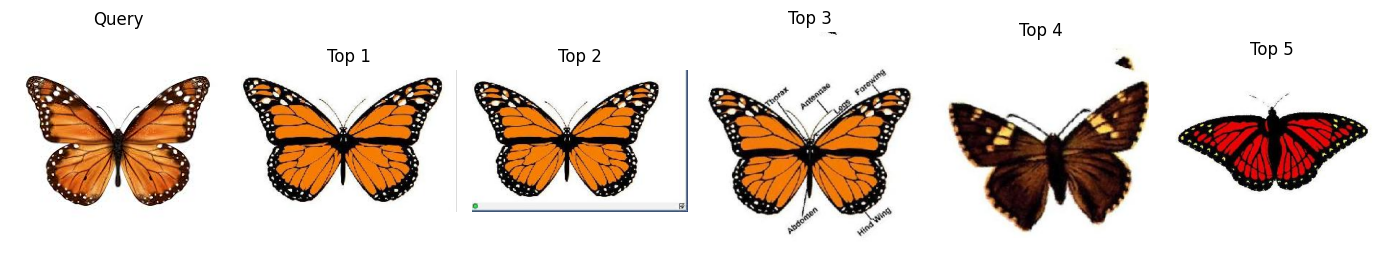

In [ ]:
import os
import cv2
import faiss
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# =========================
# 1️⃣ UNZIP DATASET
# =========================
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted")
else:
    print("✅ Dataset already extracted")

DATASET_PATH = extract_path

# =========================
# 2️⃣ LOAD IMAGE PATHS
# =========================
image_paths = []
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            image_paths.append(os.path.join(root, file))

if len(image_paths) == 0:
    raise Exception("❌ No images found!")

print("✅ Total Images:", len(image_paths))

# =========================
# 3️⃣ COLOR FEATURES
# =========================
def color_features(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    rgb_hist = cv2.calcHist([img], [0,1,2], None, [4,4,4], [0,256]*3)
    hsv_hist = cv2.calcHist([hsv], [0,1,2], None, [4,4,4], [0,256]*3)
    lab_hist = cv2.calcHist([lab], [0,1,2], None, [4,4,4], [0,256]*3)

    rgb_hist = cv2.normalize(rgb_hist, None).flatten()
    hsv_hist = cv2.normalize(hsv_hist, None).flatten()
    lab_hist = cv2.normalize(lab_hist, None).flatten()

    return np.concatenate([rgb_hist, hsv_hist, lab_hist])

# =========================
# 4️⃣ LOAD CNN MODEL
# =========================
cnn_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(128,128,3)
)

# =========================
# 5️⃣ BATCH DEEP FEATURES
# =========================
def extract_deep_features_batch(paths, batch_size=32):
    features = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.resize(img, (128,128))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            batch_images.append(img)

        if len(batch_images) == 0:
            continue

        batch_images = np.array(batch_images, dtype=np.float32)
        batch_images = preprocess_input(batch_images)

        preds = cnn_model.predict(batch_images, verbose=0)

        for p in preds:
            features.append(p.flatten())

        print(f"🔄 Processed {min(i+batch_size, len(paths))}/{len(paths)}")

    return np.array(features)

# =========================
# 6️⃣ FEATURE FUSION
# =========================
def feature_fusion(color_feat, deep_feat):
    color_feat = color_feat / (np.linalg.norm(color_feat) + 1e-8)
    deep_feat = deep_feat / (np.linalg.norm(deep_feat) + 1e-8)

    fused = np.concatenate([0.3 * color_feat, 0.7 * deep_feat])
    return fused / (np.linalg.norm(fused) + 1e-8)

# =========================
# 7️⃣ BUILD DATABASE
# =========================
print("🚀 Extracting deep features...")
deep_feats = extract_deep_features_batch(image_paths)

database_features = []
valid_image_paths = []

for i, path in enumerate(image_paths):
    img = cv2.imread(path)
    if img is None:
        continue

    try:
        color_feat = color_features(img)
        deep_feat = deep_feats[i]

        fused = feature_fusion(color_feat, deep_feat)

        database_features.append(fused)
        valid_image_paths.append(path)

    except Exception as e:
        print(f"⚠️ Skipping {path}: {e}")

database_features = np.array(database_features).astype('float32')

print("✅ Feature DB shape:", database_features.shape)

# =========================
# 8️⃣ FAISS INDEX
# =========================
faiss.normalize_L2(database_features)

dimension = database_features.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(database_features)

print("✅ FAISS Index Built")

# =========================
# 9️⃣ UPLOAD QUERY IMAGE
# =========================
from google.colab import files
uploaded = files.upload()

query_image = list(uploaded.keys())[0]

# =========================
# 🔟 RETRIEVAL FUNCTION
# =========================
def retrieve(query_path, top_k=5):

    img = cv2.imread(query_path)
    if img is None:
        print("❌ Invalid query image")
        return []

    color_feat = color_features(img)

    img_resized = cv2.resize(img, (128,128))
    img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_resized = np.expand_dims(img_resized, axis=0)
    img_resized = preprocess_input(img_resized)

    deep_feat = cnn_model.predict(img_resized, verbose=0).flatten()

    fused = feature_fusion(color_feat, deep_feat)
    fused = np.array([fused]).astype('float32')

    faiss.normalize_L2(fused)

    distances, indices = index.search(fused, top_k)
    return indices[0]

# =========================
# 1️⃣1️⃣ RETRIEVE RESULTS
# =========================
indices = retrieve(query_image)

# =========================
# 1️⃣2️⃣ DISPLAY RESULTS
# =========================
plt.figure(figsize=(14,5))

# Query Image
plt.subplot(1, len(indices)+1, 1)
q_img = cv2.imread(query_image)
plt.imshow(cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")

# Retrieved Images
for i, idx in enumerate(indices):
    img = cv2.imread(valid_image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(indices)+1, i+2)
    plt.imshow(img)
    plt.title(f"Top {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()